<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
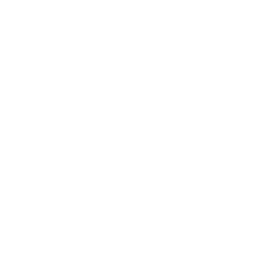
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse de similarité des programmes d'études</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Enseignement supérieur / Conception de programmes académiques &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Synthèse

Ce notebook mesure le recouvrement des programmes d'études à travers un
catalogue de cours universitaires à l'aide de **PROC DISTANCE** avec
**METHOD=DJACCARD** — le coefficient de *dissimilarité* de Jaccard, la
distance naturelle pour des données binaires de présence/absence. Chaque
cours porte 40 indicateurs binaires marquant quels acquis
d'apprentissage d'accréditation il couvre, si bien que la distance de
Jaccard entre deux cours est la proportion des acquis couverts qu'ils
**ne** partagent **pas** (0 = ensembles d'acquis identiques, 1 = aucun
acquis commun).

L'analyse se déroule en deux parties. D'abord, sur un catalogue de 100
cours, elle profile l'étendue de la couverture des acquis par
département (PROC MEANS, PROC FREQ, un box plot de couverture) et
signale les acquis d'apprentissage qu'**aucun** cours d'un département
ne couvre (lacunes de couverture). Ensuite, elle se concentre sur un
panel ciblé de 10 cours tirés des deux départements au recouvrement
quantitatif le plus fort — Statistique et Science des données —, calcule
la matrice complète des distances de Jaccard par paires, et classe les
paires de cours les plus proches comme candidats à un examen de
consolidation. L'objectif est de fournir à un comité de programme deux
artefacts concrets : une liste classée des cours les plus similaires et
une carte des lacunes département par acquis.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Couverture binaire des acquis d'apprentissage par cours (40 indicateurs d'acquis) | 100 |
| WORK.PANEL10 | Panel de consolidation Statistique + Science des données | 10 |

Le catalogue est synthétique. Les indicateurs d'acquis sont tirés avec
des probabilités spécifiques au département afin que les disciplines
mettent l'accent sur des groupes d'acquis différents (l'informatique et
les mathématiques pondèrent les premiers acquis, les sciences
expérimentales pondèrent la bande médiane), donnant à l'analyse de
distance une structure réaliste. Cet environnement s'exécute sans
licence, si bien que le catalogue de travail est plafonné à 100 cours.


---

In [1]:
/* --------------------------------------------------------
   Générer une matrice synthétique acquis-cours
   500 cours x 40 acquis d'apprentissage d'accréditation
   (le mode sans licence conserve les 100 premiers)
   -------------------------------------------------------- */
DONNÉES work.course_outcomes;
    APPELER streaminit(42);
    LONGUEUR department $24;
    TABLEAU outcomes[40] lo_1 - lo_40;
    FAIRE course_id = 1 JUSQU_À 500;
        course_label = cat('CRS', ÉCRIRE(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        SÉLECTIONNER (dept_idx);
            QUAND (1) department = 'INFORMATIQUE';
            QUAND (2) department = 'MATHÉMATIQUES';
            QUAND (3) department = 'STATISTIQUE';
            QUAND (4) department = 'INGÉNIERIE';
            QUAND (5) department = 'BIOLOGIE';
            QUAND (6) department = 'CHIMIE';
            QUAND (7) department = 'PHYSIQUE';
            QUAND (8) department = 'SCIENCE_DONNÉES';
            AUTREMENT;
        FIN;
        /* Le niveau du cours influe sur l'étendue des acquis */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Groupes d'acquis spécifiques au département */
        FAIRE lo = 1 JUSQU_À 40;
            base_prob = 0.15;
            /* Dépt 1-2 (Info, Maths) : accent sur les acquis 1-15 */
            SI dept_idx <= 2 AND lo <= 15 ALORS
                base_prob = 0.4 + course_level * 0.05;
            /* Dépt 3-4 (Stat, Ingénierie) : accent sur les acquis 10-25 */
            SINON SI dept_idx DANS (3, 4) AND 10 <= lo <= 25 ALORS
                base_prob = 0.35 + course_level * 0.05;
            /* Dépt 5-7 (Bio, Chimie, Phys) : accent sur 20-35 */
            SINON SI dept_idx DANS (5, 6, 7) AND 20 <= lo <= 35 ALORS
                base_prob = 0.38 + course_level * 0.04;
            /* Dépt 8 (Science des données) : couverture large */
            SINON SI dept_idx = 8 ALORS
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        FIN;
        SORTIE;
    FIN;
    SUPPRIMER dept_idx course_level base_prob lo;
EXÉCUTER;



NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.90 seconds
  cpu   1.90 seconds


In [2]:
/* --------------------------------------------------------
   Générer les métadonnées du catalogue de cours
   -------------------------------------------------------- */
DONNÉES work.course_catalog;
    APPELER streaminit(43);
    LONGUEUR department $24;
    TABLEAU format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    FAIRE course_id = 1 JUSQU_À 500;
        course_label = cat('CRS-', ÉCRIRE(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        SÉLECTIONNER (dept_idx);
            QUAND (1) department = 'INFORMATIQUE';
            QUAND (2) department = 'MATHÉMATIQUES';
            QUAND (3) department = 'STATISTIQUE';
            QUAND (4) department = 'INGÉNIERIE';
            QUAND (5) department = 'BIOLOGIE';
            QUAND (6) department = 'CHIMIE';
            QUAND (7) department = 'PHYSIQUE';
            QUAND (8) department = 'SCIENCE_DONNÉES';
            AUTREMENT;
        FIN;
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        SORTIE;
    FIN;
    SUPPRIMER dept_idx format_idx;
    format last_offered date9.;
EXÉCUTER;



NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


---

                                     Couverture moyenne des acquis par département                                      

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                               N
                                         Département         Obs           Mean
                                         --------------------------------------
                                         BIOLOGIE             10      0.2000000
                                         CHIMIE               19      0.2105263
                                         INFORMATIQUE         13      0.3846154
                                         INGÉNIERIE           17      0.0000000
                                         MATHÉMATIQUES         9      0.6666667
                                         PHYSIQUE              7      0.2857143
                             


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


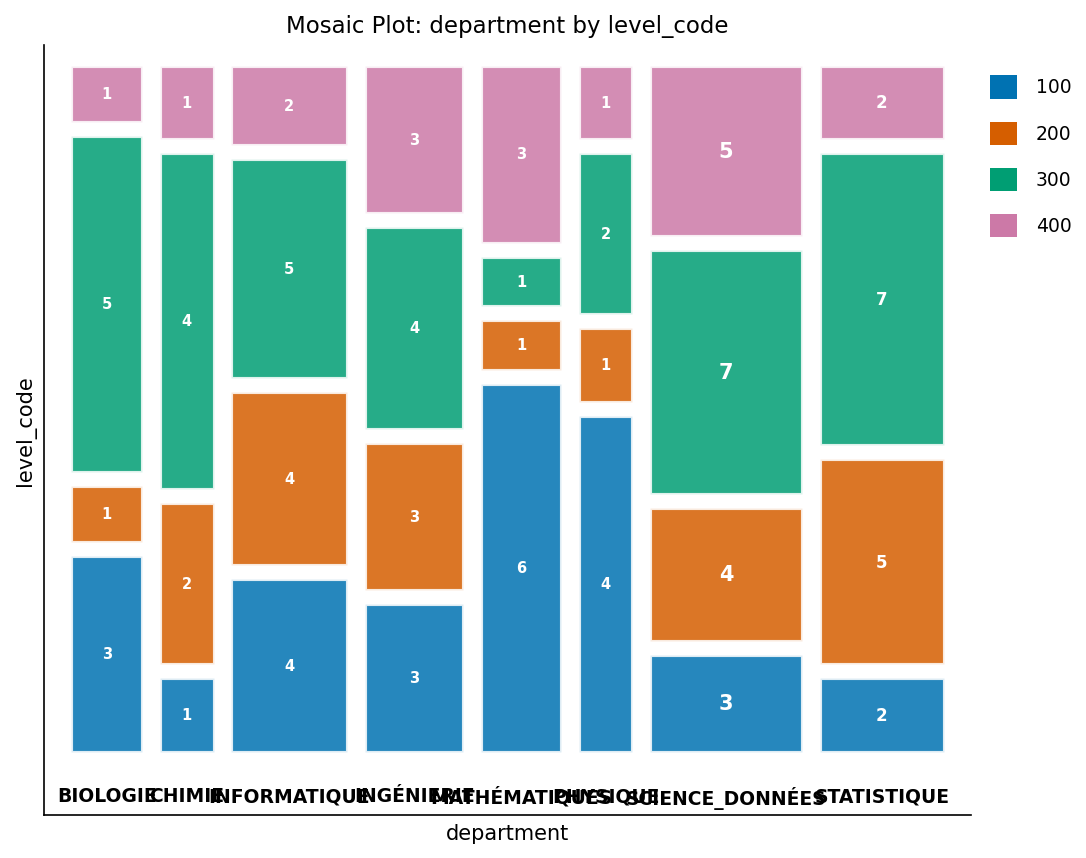

In [3]:
/* --------------------------------------------------------
   Couverture initiale des acquis d'apprentissage par département
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.course_outcomes mean;
    CLASSE department;
    VAR lo_1 - lo_40;
    ÉTIQUETTE department='Département';
    TITRE 'Couverture moyenne des acquis par département';
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    ÉTIQUETTE department='Département' level_code='Niveau';
    TITRE 'Répartition des cours par département et niveau';
EXÉCUTER;


---

                                    Répartition des cours par département et niveau                                     




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


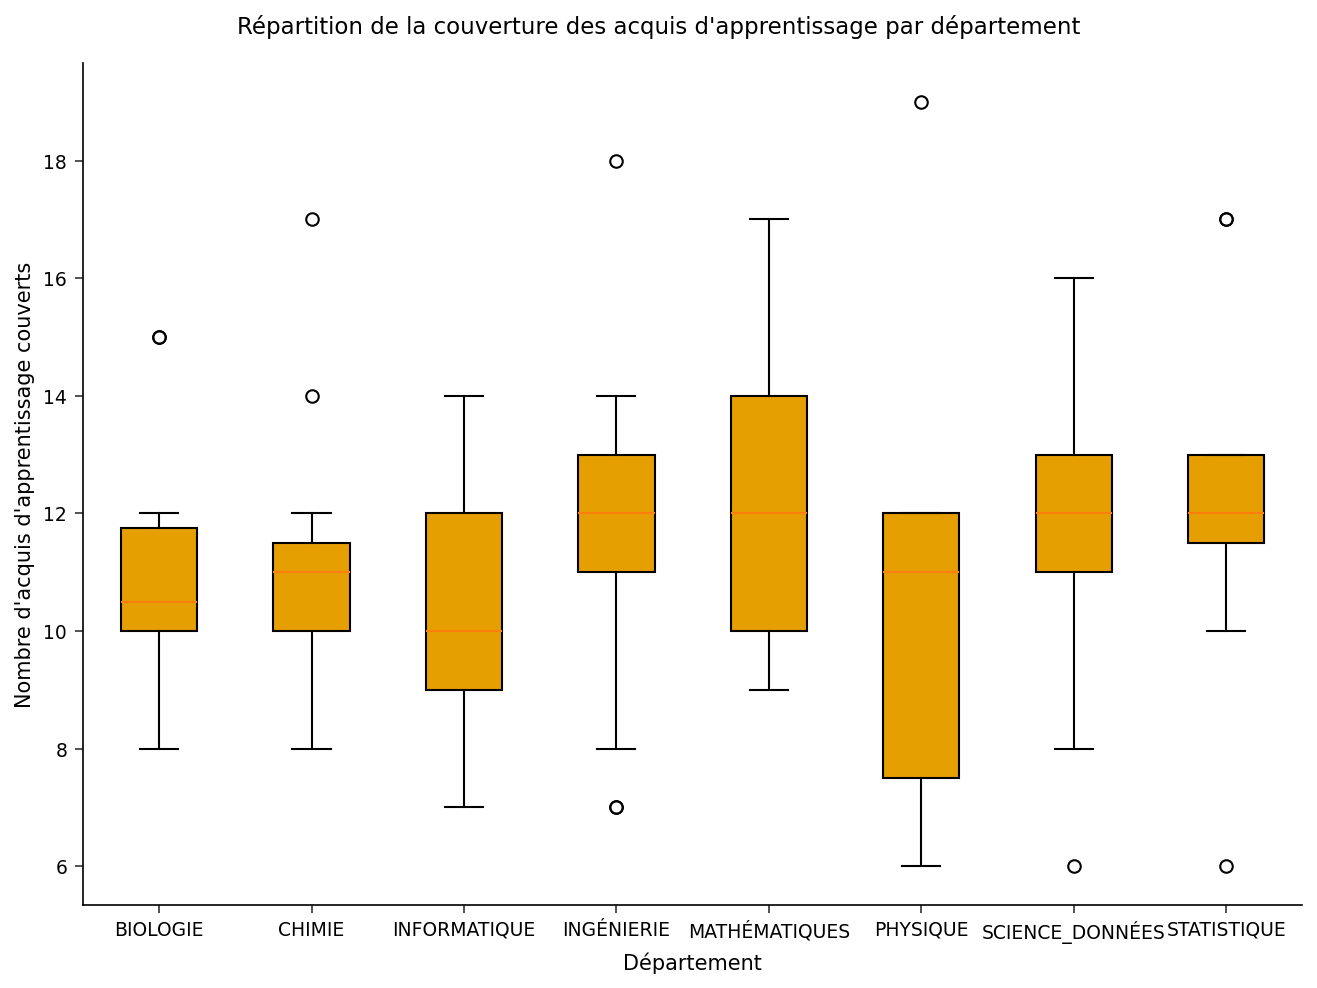

In [4]:
/* --------------------------------------------------------
   Densité de couverture des acquis par département
   -------------------------------------------------------- */
DONNÉES work.outcome_counts;
    DÉFINIR work.course_outcomes;
    TABLEAU outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(DE outcomes[*]);
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=work.outcome_counts;
    VBOX total_outcomes / category=department;
    ÉTIQUETTE department='Département' total_outcomes="Nombre d'acquis d'apprentissage couverts";
    YAXIS ÉTIQUETTE="Nombre d'acquis d'apprentissage couverts";
    XAXIS ÉTIQUETTE='Département';
    TITRE "Répartition de la couverture des acquis d'apprentissage par département";
EXÉCUTER;


---

In [5]:
/* --------------------------------------------------------
   Panel de consolidation : les 10 premiers cours de
   Statistique / Science des données (les deux départements
   au recouvrement quantitatif le plus fort). On les renomme
   P01-P10 avec un compteur séquentiel pour que la matrice de
   distances OUT= carrée ait des colonnes propres et
   adressables, puis on calcule la matrice complète des
   distances de Jaccard par paires avec METHOD=DJACCARD
   (0 = ensembles d'acquis identiques, 1 = aucun acquis commun).
   -------------------------------------------------------- */
DONNÉES work.panel10;
    DÉFINIR work.course_outcomes(OÙ=(department DANS ('STATISTIQUE' 'SCIENCE_DONNÉES')));
    RETENIR seq 0;
    seq + 1;
    SI seq > 10 ALORS ARRÊTER;
    panel_id = cat('P', ÉCRIRE(seq, z2.));
    SUPPRIMER seq;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.panel10 noobs ÉTIQUETTE;
    VAR panel_id course_label department level_code;
    ÉTIQUETTE panel_id = 'ID panneau' course_label = 'Cours'
          department = 'Département' level_code = 'Niveau';
    TITRE 'Panneau de consolidation : cours de statistique et de science des données';
EXÉCUTER;

PROCÉDURE distance DONNÉES=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VAR nominal(lo_1 - lo_40);
    id panel_id;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.panel_dist noobs;
    TITRE 'Matrice des distances de Jaccard par paires (10 cours)';
EXÉCUTER;


                       Panneau de consolidation : cours de statistique et de science des données                        

ID panneau    Cours       Département  Niveau
P01         CRS0003  SCIENCE_DONNÉES      300
P02         CRS0006  STATISTIQUE          300
P03         CRS0014  SCIENCE_DONNÉES      300
P04         CRS0015  STATISTIQUE          300
P05         CRS0017  STATISTIQUE          200
P06         CRS0019  SCIENCE_DONNÉES      100
P07         CRS0022  STATISTIQUE          400
P08         CRS0033  SCIENCE_DONNÉES      200
P09         CRS0038  STATISTIQUE          100
P10         CRS0040  STATISTIQUE          100

                       Panneau de consolidation : cours de statistique et de science des données                        

                                 Matrice des distances de Jaccard par paires (10 cours)                                 

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08         


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Restructurer la matrice de distances carrée en une liste
   classée de paires de cours. Les colonnes de distance du
   OUT= sont adressées par une liste de noms explicite
   (P01 P02 ... P10) ; seul le triangle supérieur strict
   (col > row) est conservé pour que chaque paire non
   ordonnée apparaisse une fois et que la diagonale nulle
   soit ignorée. Les cinq paires les plus proches sont les
   candidats à l'examen de consolidation.
   -------------------------------------------------------- */
DONNÉES work.similar_courses;
    DÉFINIR work.panel_dist;
    TABLEAU d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LONGUEUR course_a course_b $8;
    course_a = _name_;
    row + 1;
    FAIRE col = 1 JUSQU_À 10;
        SI col > row ALORS FAIRE;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            SORTIE;
        FIN;
    FIN;
    GARDER course_a course_b jaccard_dist;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VAR jaccard_dist;
    ÉTIQUETTE jaccard_dist='Distance de Jaccard';
    TITRE 'Distribution des distances de Jaccard par paires (45 paires de cours)';
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=work.similar_courses; PAR jaccard_dist; EXÉCUTER;

DONNÉES work.top_pairs;
    DÉFINIR work.similar_courses;
    pair_rank = _n_;
    SI pair_rank <= 5;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.top_pairs noobs ÉTIQUETTE;
    VAR pair_rank course_a course_b jaccard_dist;
    ÉTIQUETTE pair_rank = 'Rang' course_a = 'Cours A'
          course_b = 'Cours B' jaccard_dist = 'Distance de Jaccard';
    TITRE 'Cinq paires de cours les plus proches (candidats à la consolidation)';
EXÉCUTER;


                         Distribution des distances de Jaccard par paires (45 paires de cours)                          

                                                  The MEANS Procedure

 Variable      Label                      N     Minimum   Lower Quartile      Median        Mean     Maximum
 -----------------------------------------------------------------------------------------------------------
 jaccard_dist  Distance de Jaccard       45       0.588            0.762       0.826       0.818       0.962
 -----------------------------------------------------------------------------------------------------------

                          Cinq paires de cours les plus proches (candidats à la consolidation)                          

Rang  Cours A  Cours B  Distance de Jaccard
   1  P02      P10                    0.588
   2  P03      P04                      0.6
   3  P03      P05                    0.667
   4  P02      P04                    0.684
   5  P02      P07          


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                  Acquis d'apprentissage non couverts par département                                   

                                                   The FREQ Procedure

Département       Frequency    Percent
---------------------------------------
BIOLOGIE                  8     26.67
CHIMIE                    2      6.67
INFORMATIQUE              3     10.00
INGÉNIERIE                2      6.67
MATHÉMATIQUES             4     13.33
PHYSIQUE                  8     26.67
STATISTIQUE               3     10.00
                                 Échantillon de lacunes d'acquis (12 premières sur 30)                                  

 Département  Acquis non couvert
BIOLOGIE      LO02
BIOLOGIE      LO10
BIOLOGIE      LO15
BIOLOGIE      LO16
BIOLOGIE      LO17
BIOLOGIE      LO18
BIOLOGIE      LO36
BIOLOGIE      LO37
CHIMIE        LO02
CHIMIE        LO12
INFORMATIQUE  LO29
INFORMATIQUE  LO35

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


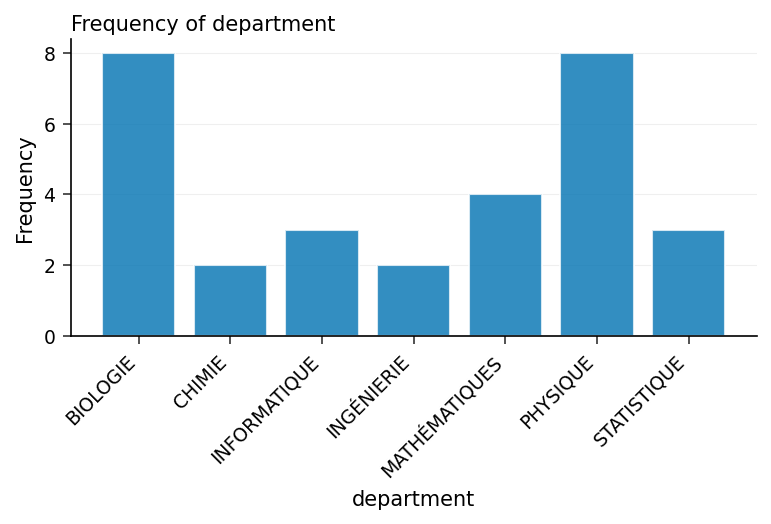

In [7]:
/* --------------------------------------------------------
   Lacunes d'acquis : les acquis d'apprentissage qu'AUCUN
   cours d'un département ne couvre. PROC MEANS somme chaque
   indicateur binaire d'acquis au sein du département ; une
   somme nulle signifie que l'acquis est absent du catalogue
   de ce département.
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.course_outcomes sum SANS_IMPRESSION;
    CLASSE department;
    VAR lo_1 - lo_40;
    SORTIE out=work.dept_coverage(OÙ=(_type_=1))
        sum=lo_1 - lo_40;
EXÉCUTER;

DONNÉES work.outcome_gaps;
    DÉFINIR work.dept_coverage;
    TABLEAU outcomes[40] lo_1 - lo_40;
    FAIRE lo = 1 JUSQU_À 40;
        outcome_id = cat('LO', ÉCRIRE(lo, z2.));
        courses_covering = outcomes[lo];
        SI courses_covering = 0 ALORS FAIRE;
            gap_flag = 1;
            SORTIE;
        FIN;
    FIN;
    GARDER department outcome_id courses_covering gap_flag;
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=work.outcome_gaps;
    TABLES department / nocum;
    ÉTIQUETTE department='Département';
    TITRE "Acquis d'apprentissage non couverts par département";
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.outcome_gaps(obs=12) noobs ÉTIQUETTE;
    VAR department outcome_id;
    ÉTIQUETTE department = 'Département' outcome_id = 'Acquis non couvert';
    TITRE "Échantillon de lacunes d'acquis (12 premières sur 30)";
EXÉCUTER;


---

### Interprétation

**Panel de consolidation.** Sur les 45 paires non ordonnées du panel de
10 cours Statistique / Science des données, la distance de Jaccard
varie de 0,588 à 0,962 avec une médiane de 0,826 (moyenne 0,818). La
paire la plus proche est P02 et P10 à une distance de 0,588, suivie de
P03–P04 à 0,600 et P03–P05 à 0,667. Même les cours les plus
similaires diffèrent encore sur environ 59 % de leurs acquis
couverts, si bien que ce catalogue ne contient **aucun cours quasi
identique** — il n'existe aucune paire qu'un comité pourrait fusionner
purement et simplement. La liste classée oriente plutôt vers la poignée
de paires méritant une comparaison manuelle des syllabus avant le
prochain cycle de catalogue ; les paires à distance la plus élevée
(proches de 0,962) confirment que les cours de Statistique et de Science
des données, bien que partageant un voisinage départemental, couvrent
des ensembles d'acquis réellement distincts.

**Lacunes d'acquis.** Trente lacunes département-par-acquis apparaissent
à travers le catalogue. Les disciplines fortement expérimentales en
portent le plus : la **Biologie** et la **Physique** laissent chacune 8
des 40 acquis d'accréditation non couverts, suivies des **Mathématiques**
(4). Les départements quantitatifs sont les mieux couverts — la
**Chimie** et l'**Ingénierie** ne manquent que 2 acquis chacun. Ces
lacunes sont les cibles naturelles pour le développement de nouveaux
cours ou l'inscription croisée : un acquis absent d'un département entier
est un risque de couverture au renouvellement d'accréditation, tandis
que la liste de consolidation traite le problème inverse de l'effort
redondant. Ensemble, les deux artefacts permettent au comité de resserrer
le catalogue des deux côtés — en réduisant le recouvrement et en
comblant les déserts — au moyen d'une seule mesure de distance ensembliste.


---

In [8]:
/* --------------------------------------------------------
   Exporter les candidats de consolidation classés et la
   carte des lacunes d'acquis par département pour le comité
   de programme.
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>